## Imports

In [2]:
import os,glob
import random
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.nn as nn
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50 
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.utils import shuffle

## Load The Data

In [3]:
path='/kaggle/input/diabetic-retinopathy'
if not os.path.exists(path):
    print("Dataset folder not found at:", path)
    print("Download and extract the Kaggle dataset to that path.")
    raise SystemExit(1)

# 1) discover classes and image paths
class_dirs = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
if not class_dirs:
    print("No class subfolders found. Expect: data/diabetic_retinopathy/<class>/*.jpg")
    raise SystemExit(1)

print("Found classes:", class_dirs)
image_paths = []
labels = []
for idx, cls in enumerate(class_dirs):
    files = glob.glob(os.path.join(path, cls, "*"))
    files = [f for f in files if os.path.splitext(f)[1].lower() in (".jpg", ".jpeg", ".png")]
    for f in files:
        image_paths.append(f)
        labels.append(idx)

print("Total images:", len(image_paths))
if len(image_paths) == 0:
    print("No images found - check paths.")
    raise SystemExit(1)

Found classes: ['Healthy', 'Mild DR', 'Moderate DR', 'Proliferate DR', 'Severe DR']
Total images: 1986


In [4]:
combined=list(zip(image_paths,labels))
random.seed(42)
random.shuffle(combined)
image_paths,labels = zip(*combined)
image_paths=list(image_paths)
labels=list(labels)

In [5]:
n =len(image_paths)
train_frac = 0.70
val_frac = 0.15 
n_train = int(n* train_frac)
n_val = int(n*val_frac)
n_test = n - n_train - n_val

In [6]:
train_paths = image_paths[:n_train]
train_labels =labels[:n_train]
val_paths = image_paths[n_train:n_train+n_val]
val_labels = labels[n_train:n_train+n_val]
test_paths = image_paths[n_train+n_val:]
test_labels = labels[n_train+n_val:]

In [7]:
print("Split sizes -> train:", len(train_paths), "val:", len(val_paths), "test:", len(test_paths))

Split sizes -> train: 1390 val: 297 test: 299


In [8]:
dist = pd.DataFrame({
    "train": pd.Series(train_labels).value_counts().sort_index(),
    "val": pd.Series(val_labels).value_counts().sort_index(),
    "test": pd.Series(test_labels).value_counts().sort_index()
}).fillna(0).astype(int)
print("\nClass distribution (by index):\n", dist)


Class distribution (by index):
    train  val  test
0    354   86    85
1    268   54    48
2    424   84    91
3    202   46    42
4    142   27    33


In [9]:
image_size =(224,224)
batch_size = 32 # or 64 
NUM_CLASSES = len(dist.index)

# Data Generators
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    zoom_range = 0.2,
    horizontal_flip = True
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [10]:
train_df = pd.DataFrame({
    "filename": train_paths,
    "class": list(map(str, train_labels))
})

val_df = pd.DataFrame({
    "filename": val_paths,
    "class": list(map(str, val_labels))
})

test_df = pd.DataFrame({
    "filename": test_paths,
    "class": list(map(str, test_labels))
})

In [11]:
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)
val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 1390 validated image filenames belonging to 5 classes.
Found 297 validated image filenames belonging to 5 classes.


## Model

In [12]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

I0000 00:00:1761117733.084313      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
for layer in base_model.layers:
    layers.trainable= False

#compile 
model.compile(optimizer=Adam(learning_rate=1e-4),loss='categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1761117795.099434     112 service.cc:148] XLA service 0x7bf9e4002220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761117795.100337     112 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1761117799.928395     112 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/44 ━━━━━━━━━━━━━━━━━━━━ 55:02 77s/step - accuracy: 0.2812 - loss: 1.7801

I0000 00:00:1761117820.680044     112 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


44/44 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.4193 - loss: 1.4257 - val_accuracy: 0.2896 - val_loss: 2.5414
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 447ms/step - accuracy: 0.5604 - loss: 1.0813 - val_accuracy: 0.0909 - val_loss: 2.2644
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 449ms/step - accuracy: 0.6438 - loss: 0.8987 - val_accuracy: 0.2155 - val_loss: 1.7209
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 450ms/step - accuracy: 0.6665 - loss: 0.7877 - val_accuracy: 0.2896 - val_loss: 2.3165
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 455ms/step - accuracy: 0.6988 - loss: 0.7652 - val_accuracy: 0.2896 - val_loss: 2.4649
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 460ms/step - accuracy: 0.6765 - loss: 0.7863 - val_accuracy: 0.2896 - val_loss: 3.4978
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 467ms/step - accuracy: 0.7437 - loss: 0.6323 - val_accuracy: 0.2896 - val_loss: 2.8702
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 451ms/step - accuracy: 0.7769 - loss: 0.5599 - val_accuracy: 0.2896 

## Fine-tune Model

In [17]:
# Fine-tune: Unfreeze the top layers 
for layer in base_model.layers[-20:]: 
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_resnet50.h5', save_best_only=True)
]
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8943 - loss: 0.2785 - val_accuracy: 0.2963 - val_loss: 1.7317
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 604ms/step - accuracy: 0.9275 - loss: 0.2095 - val_accuracy: 0.2929 - val_loss: 1.7096
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 24s 545ms/step - accuracy: 0.9429 - loss: 0.1905 - val_accuracy: 0.3266 - val_loss: 1.7271
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 486ms/step - accuracy: 0.9533 - loss: 0.1525 - val_accuracy: 0.4040 - val_loss: 1.8395
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 492ms/step - accuracy: 0.9501 - loss: 0.1655 - val_accuracy: 0.4411 - val_loss: 2.2443
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 477ms/step - accuracy: 0.9595 - loss: 0.1353 - val_accuracy: 0.4175 - val_loss: 2.8536
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 488ms/step - accuracy: 0.9375 - loss: 0.1706 - val_accuracy: 0.3973 - val_loss: 3.2676


In [18]:
test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 299 validated image filenames belonging to 5 classes.


## Results

In [19]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 515ms/step - accuracy: 0.2921 - loss: 1.7785

✅ Test Accuracy: 0.2742


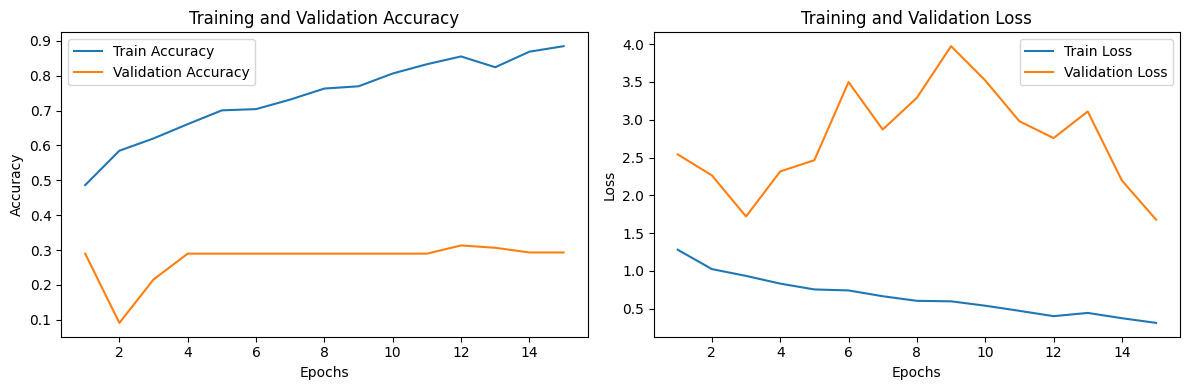

In [20]:
acc = history.history.get('accuracy', [])
val_acc = history.history.get('val_accuracy', [])
loss = history.history.get('loss', [])
val_loss = history.history.get('val_loss', [])
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


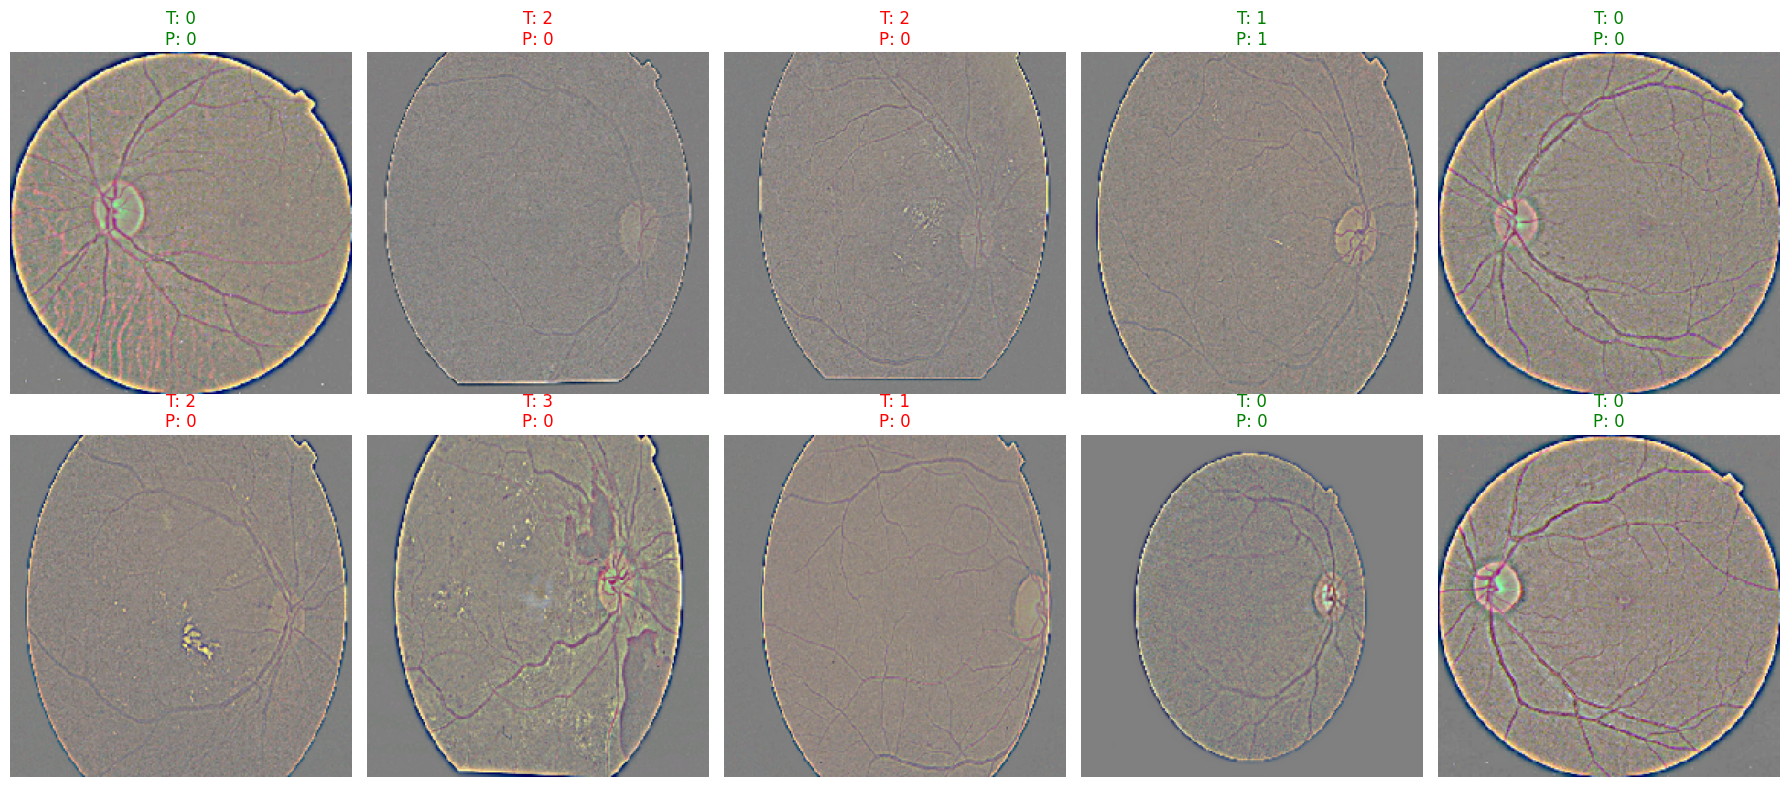

In [21]:
# Get one batch from the test generator
batch_images, batch_labels = next(iter(test_gen))

# Make predictions
preds = model.predict(batch_images)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(batch_labels, axis=1)

# Get class names from the generator
class_dirs = list(test_gen.class_indices.keys())

# Plot first 10 images with true and predicted labels
plt.figure(figsize=(18, 8))
for i in range(min(10, len(batch_images))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(batch_images[i])
    plt.axis('off')
    plt.title(f"T: {class_dirs[true_labels[i]]}\nP: {class_dirs[pred_labels[i]]}",
              color='green' if true_labels[i] == pred_labels[i] else 'red')

plt.tight_layout()
plt.show()